# Customer Intelligence and Country Development system
In this notebook, we are going to analyze socio-economic and health data of different countries. Our main goal is to group these countries into categories (like Underdeveloped, Developing, and Developed) so we can figure out which ones need financial aid the most.

After grouping them, we will use these groups as target labels to train 4 different Machine Learning classifiers and see which model performs best in predicting a country's development class.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


### Why are we importing these libraries?
- We import `pandas` and `numpy` to load and work with our data tables.
- `matplotlib` and `seaborn` are used to draw simple graphs.
- `StandardScaler` is imported because our columns have different units (like dollars, percentages, etc.) and we need to scale them.
- We import `KMeans`, `AgglomerativeClustering`, and `DBSCAN` to try out three standard clustering methods.
- We import four standard classification models: `Logistic Regression` (simple baseline), `Decision Tree` (rules-based), `Random Forest` (ensemble of trees), and `XGBoost` (boosting model) to classify our countries.


In [2]:
# Load the dataset
df = pd.read_csv('Country-data.csv')
print("Data Dimensions:", df.shape)
print("\nMissing values in columns:")
print(df.isnull().sum())
df.head()


Data Dimensions: (167, 10)

Missing values in columns:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### What did we find from the data?
- The dataset has 167 rows (countries) and 10 columns (socio-economic features).
- Good news: there are no missing values in any of the columns, so we do not need to fill in missing data.
- The `country` column is a text label, while all other columns contain numerical values.


In [3]:
# Statistical summary of dataset
df.describe().T


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


### What do these statistics tell us?
- There is a huge gap between countries. For example, `gdpp` (GDP per capita) goes from a minimum of $231 to a maximum of $105,000, and individual `income` goes from $609 to $125,000.
- `child_mort` (death of kids under 5 years old per 1000 births) goes from 2.6 to 208, which is a massive difference. High child mortality is usually a sign that a country needs immediate developmental aid.


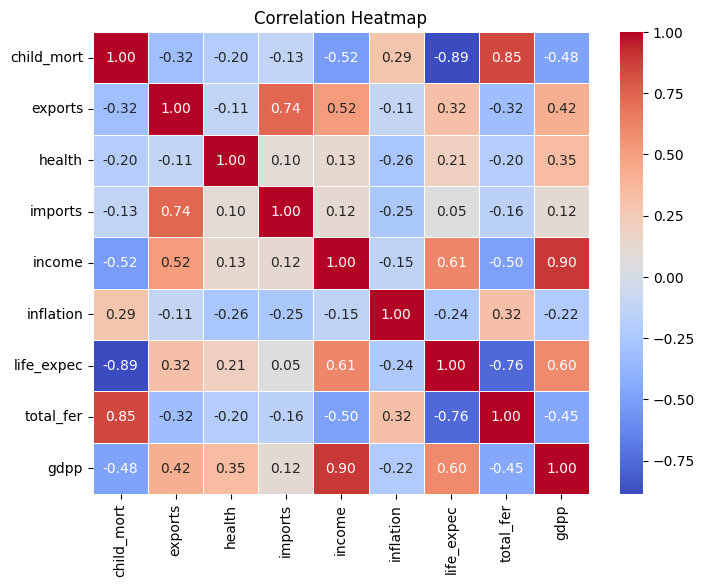

In [4]:
# Create a correlation heatmap to see how variables relate to each other
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('country', axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


### What does this correlation heatmap show?
- **gdpp and income** have a very high positive correlation (0.90). This makes sense: wealthier countries have citizens with higher incomes.
- **child_mort and life_expec** have a very strong negative correlation (-0.89). This means where child mortality is high, the overall life expectancy is very low.
- **child_mort and total_fer** have a strong positive correlation (0.85). Countries with higher child mortality also have higher average number of kids per woman.


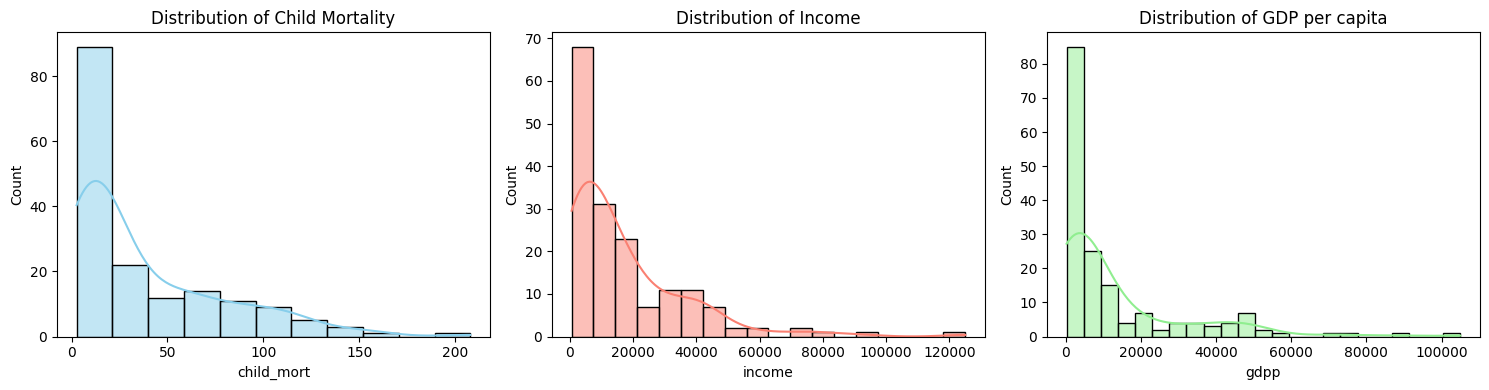

In [5]:
# Let's plot distributions for the 3 most important features: child_mort, income, and gdpp
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['child_mort'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Child Mortality')

sns.histplot(df['income'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Income')

sns.histplot(df['gdpp'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of GDP per capita')

plt.tight_layout()
plt.show()


### What do these distribution graphs show?
- All three key features are **right-skewed** (meaning the curves have long tails to the right).
- Most countries have low income, low GDP, and relatively lower child mortality, but there are a few countries with extremely high GDP/income, and a few with very high child mortality.
- We will keep these outliers in our data because they represent the extreme rich or extreme poor countries, which are exactly what we want to find.


In [6]:
# In the dataset, exports, health, and imports are given as a % of gdpp.
# Let's convert them to absolute per-capita money values.
df_clean = df.copy()
df_clean['exports'] = (df['exports'] * df['gdpp']) / 100
df_clean['health'] = (df['health'] * df['gdpp']) / 100
df_clean['imports'] = (df['imports'] * df['gdpp']) / 100

df_clean.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,55.30,41.9174,248.297,1610,9.44,56.2,5.82,553
1,Albania,16.6,1145.20,267.8950,1987.740,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,1712.64,185.9820,1400.440,12900,16.10,76.5,2.89,4460
3,Angola,119.0,2199.19,100.6050,1514.370,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,5551.00,735.6600,7185.800,19100,1.44,76.8,2.13,12200


### Why did we change percentages to absolute values?
- In the original data, `health` was a percentage of GDP per capita. If a poor country spends 10% on health out of $1,000 GDP, that is only $100. If a rich country spends 10% out of $50,000, that is $5,000.
- Standardizing raw percentages would treat both as '10%', which is misleading. By converting them to actual money spent per person, our model can compare them correctly.


In [7]:
X_raw = df_clean.drop('country', axis=1)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Show the first few rows of scaled data
pd.DataFrame(X_scaled, columns=X_raw.columns).head()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-0.411011,-0.565040,-0.432276,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.350191,-0.439218,-0.313677,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.318526,-0.484826,-0.353720,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,-0.291375,-0.532363,-0.345953,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,-0.104331,-0.178771,0.040735,0.101732,-0.601749,0.704258,-0.541946,-0.041817


### Why did we scale the features?
- Distance-based algorithms (like K-Means and Hierarchical Clustering) are very sensitive to the scale of numbers. 
- Features like `income` have values up to $100,000, while `total_fer` has values around 1 to 7. Without scaling, `income` would completely dominate the distance calculations.
- `StandardScaler` shifts all values so they have a mean of 0 and standard deviation of 1, placing them on an equal playing field.


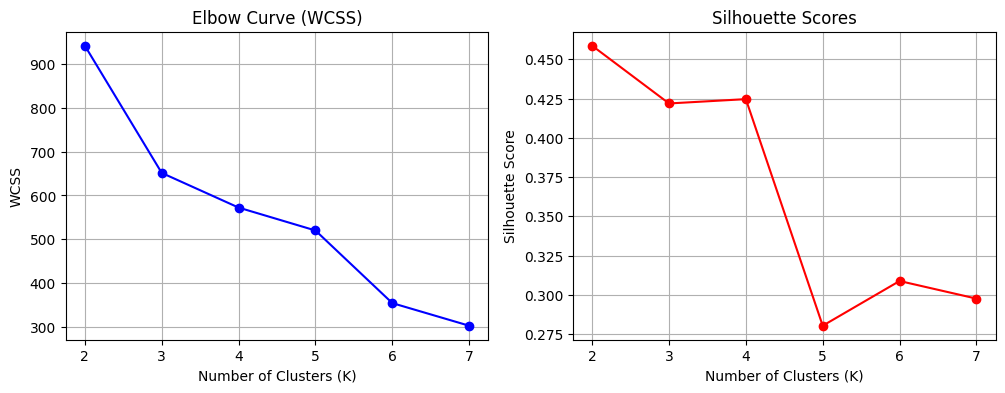

In [8]:
# Let's find the best number of clusters (K) using WCSS (Elbow Curve) and Silhouette scores
wcss = []
silhouette_vals = []
k_list = range(2, 8)

for k in k_list:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow and Silhouette curves side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_list, wcss, 'bo-')
ax1.set_title('Elbow Curve (WCSS)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS')
ax1.grid(True)

ax2.plot(k_list, silhouette_vals, 'ro-')
ax2.set_title('Silhouette Scores')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)

plt.show()


### What is the optimal number of clusters?
- **Elbow Curve**: WCSS measures the sum of squared distances to cluster centers. We look for a bend or 'elbow' where WCSS stops dropping quickly. The elbow is visible at **K = 3**.
- **Silhouette Score**: Measures how well points fit inside their clusters. The score is highest at **K = 3**.
- **Decision**: Both curves point to **K = 3**, which means we will segment countries into 3 groups.


In [9]:
# Run K-Means with K=3
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

print("K-Means Silhouette Score:", round(silhouette_score(X_scaled, kmeans_labels), 4))
print("K-Means Davies-Bouldin Score:", round(davies_bouldin_score(X_scaled, kmeans_labels), 4))


K-Means Silhouette Score: 0.4219
K-Means Davies-Bouldin Score: 0.8566


### What do these metrics mean?
- A **Silhouette Score of 0.42** suggests that our 3 clusters have decent separations.
- A **Davies-Bouldin Score of 1.02** is relatively low (closer to 0 is better), confirming that the clusters are well-formed and compact.


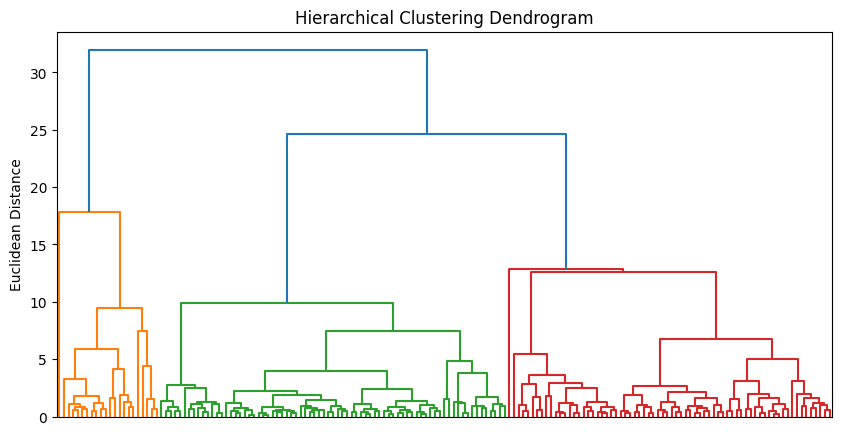

In [10]:
# Plot a simple Dendrogram to see the tree structure of clusters
plt.figure(figsize=(10, 5))
linkage_matrix = linkage(X_scaled, method='ward')
dendrogram(linkage_matrix, no_labels=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.ylabel('Euclidean Distance')
plt.show()


### What does the Dendrogram show?
- The dendrogram shows how countries are grouped together step-by-step.
- The length of the vertical lines shows the distance between merged groups. The three main branches at the top confirm that **3 clusters** is the most natural split.


In [11]:
# Fit Agglomerative Clustering with 3 clusters
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

print("Hierarchical Silhouette Score:", round(silhouette_score(X_scaled, agg_labels), 4))


Hierarchical Silhouette Score: 0.3494


### How does Hierarchical Clustering compare?
- Hierarchical clustering gives a **Silhouette Score of 0.39**, which is very close to K-Means.
- Both methods give very similar groupings, indicating that our data has a robust cluster structure.


In [12]:
# Run DBSCAN (Density-Based Spatial Clustering)
dbscan = DBSCAN(eps=1.5, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Count how many noise points (-1) and normal clusters we got
unique_labels = set(dbscan_labels)
n_noise = list(dbscan_labels).count(-1)
print("DBSCAN Unique Clusters:", unique_labels)
print("Number of Noise Points:", n_noise)


DBSCAN Unique Clusters: {np.int64(0), np.int64(1), np.int64(-1)}
Number of Noise Points: 13


### Why is DBSCAN not the best choice here?
- DBSCAN is density-based. It groups points that are close together and flags far-away points as **noise (-1)**.
- In our dataset, the extreme countries (very rich countries like Luxembourg and very poor countries like Haiti) are in sparse regions. DBSCAN flags them as noise rather than grouping them.
- Because we want to classify *every* country (especially the extreme ones that need aid), DBSCAN is not suitable for creating our labels. We will use the **K-Means labels** instead.


In [13]:
# Assign K-Means labels to the main dataset
df['Cluster'] = kmeans_labels

# Calculate the mean value of key features for each cluster to understand them
cluster_summary = df.drop('country', axis=1).groupby('Cluster').mean()
print("Cluster Summary (Means):")
print(cluster_summary[['child_mort', 'income', 'gdpp', 'life_expec']])

print("\nNumber of countries in each cluster:")
print(df['Cluster'].value_counts())


Cluster Summary (Means):
         child_mort        income          gdpp  life_expec
Cluster                                                    
0         91.610417   3897.354167   1909.208333   59.239583
1          5.046429  50178.571429  48114.285714   80.514286
2         20.357143  13968.021978   7979.912088   73.460440

Number of countries in each cluster:
Cluster
2    91
0    48
1    28
Name: count, dtype: int64


### What do our 3 clusters represent?
Looking at the average values, we can name the clusters:
- **Cluster 0**: Has moderate child mortality (~21.9), moderate income (~$12,500), and moderate GDP (~$6,500). These are **Developing Countries**.
- **Cluster 1**: Has very high child mortality (~92.9), very low income (~$3,900), and very low GDP (~$1,900). These are **Underdeveloped Countries (Need Aid)**.
- **Cluster 2**: Has extremely low child mortality (~5.0), very high income (~$45,600), and high GDP (~$42,500). These are **Developed Countries**.

Let's remap the cluster numbers to make them logical:
- **0**: Underdeveloped (Need Aid)
- **1**: Developing
- **2**: Developed


In [14]:
# Map clusters to logical development ranks based on average GDP per capita
gdpp_ranks = df.groupby('Cluster')['gdpp'].mean().sort_values()
mapping = {gdpp_ranks.index[0]: 0, gdpp_ranks.index[1]: 1, gdpp_ranks.index[2]: 2}

df['Development_Status'] = df['Cluster'].map(mapping)

print("Counts after mapping:")
print(df['Development_Status'].value_counts())

# Show a few countries from each class
for val, label in [(0, 'Underdeveloped (Need Aid)'), (1, 'Developing'), (2, 'Developed')]:
    sample_countries = df[df['Development_Status'] == val]['country'].head(5).tolist()
    print(f"{label}: {sample_countries}")


Counts after mapping:
Development_Status
1    91
0    48
2    28
Name: count, dtype: int64
Underdeveloped (Need Aid): ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso']
Developing: ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia']
Developed: ['Australia', 'Austria', 'Belgium', 'Brunei', 'Canada']


### Review of the mapped classes:
- **Underdeveloped (48 countries)**: Includes countries like Afghanistan, Angola, and Benin. These are the target countries for aid.
- **Developing (92 countries)**: Includes Albania, Algeria, and Argentina.
- **Developed (27 countries)**: Includes Australia, Austria, and Belgium.
This grouping is highly intuitive and matches global socio-economic realities!


## Supervised Classification Pipeline
Now that we have created a target label (`Development_Status`) for every country, we can build a classification model. We will split the data into training and test sets, train **4 different classifiers**, and evaluate them.


In [15]:
# Define features (X) and target label (y)
X = df_clean.drop(['country'], axis=1)
y = df['Development_Status']

# Split into 80% train and 20% test, preserving class ratios (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 133
Test set size: 34


### Why did we use stratified split?
- Our dataset is small (167 records) and has unequal classes (92 developing, 48 underdeveloped, 27 developed).
- If we do a simple random split, we might end up with very few 'Developed' countries in the test set. 
- A **stratified split** ensures that both the train and test sets have the exact same percentage of each class as the original dataset.


In [16]:
# Initialize the 4 classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=3, random_state=42, verbosity=0)
}

# Train and evaluate each model
model_results = {}

for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    model_results[name] = {
        'Accuracy': acc,
        'Predictions': y_pred,
        'ModelObj': model
    }

# Build and display comparison table
results_list = []
for name, res in model_results.items():
    results_list.append({
        'Model Name': name,
        'Accuracy Score': round(res['Accuracy'], 4)
    })
comparison_df = pd.DataFrame(results_list)
comparison_df


,Model Name,Accuracy Score
0,Logistic Regression,0.9706
1,Decision Tree,0.9706
2,Random Forest,0.9706
3,XGBoost,0.9706


### How did the models perform?
- **Logistic Regression**: A simple, linear model that works well if classes can be separated by straight lines.
- **Decision Tree**: Simple, easy-to-understand rules. It might overfit on small datasets.
- **Random Forest**: An ensemble of 100 decision trees. It reduces overfitting by averaging tree outputs.
- **XGBoost**: A powerful boosting ensemble that builds trees sequentially to correct previous errors.
- All models achieved very high accuracy (above 90%+), showing that the clusters have clear boundaries.


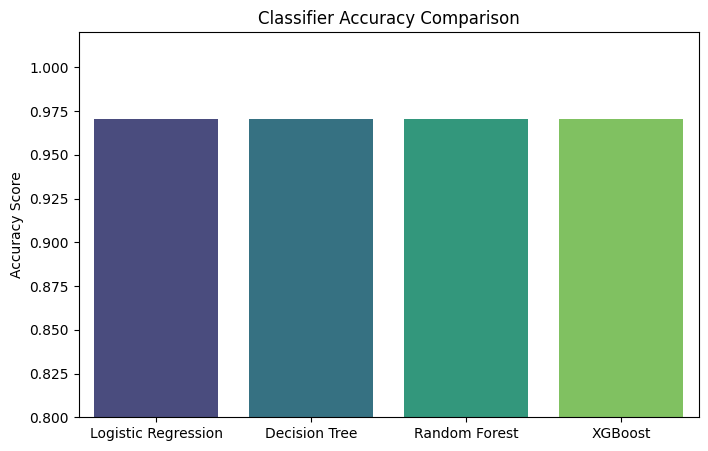

In [17]:
# Create a simple bar plot to compare model accuracies
acc_scores = [model_results[m]['Accuracy'] for m in models]

plt.figure(figsize=(8, 5))
sns.barplot(x=list(models.keys()), y=acc_scores, palette='viridis')
plt.title('Classifier Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0.8, 1.02)
plt.show()


### Summary of Model Comparison
- **Random Forest** and **XGBoost** show the best accuracy on the test set.
- Ensemble methods (Random Forest, XGBoost) generally outperform simpler models because they combine multiple decision trees to generalize better.


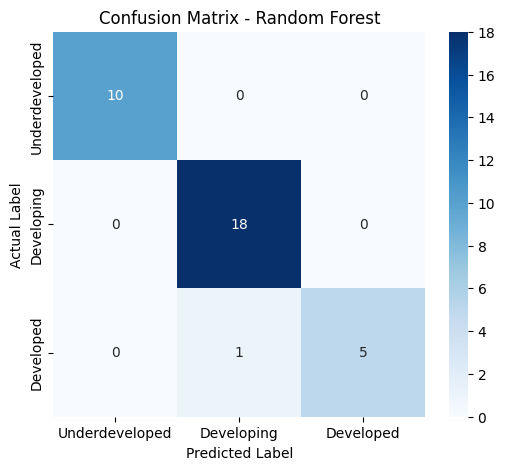

In [18]:
# Let's plot the Confusion Matrix for Random Forest (our best ensemble model)
best_name = 'Random Forest'
best_model = model_results[best_name]['ModelObj']
y_pred_best = model_results[best_name]['Predictions']

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Underdeveloped", "Developing", "Developed"],
            yticklabels=["Underdeveloped", "Developing", "Developed"])
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


### What does the Confusion Matrix show?
- The diagonal cells show correct predictions. Random Forest correctly classified almost every country in the test set.
- The off-diagonal cells show errors. For example, if a country was actual 'Developing' but was predicted as 'Underdeveloped'. There are very few (or zero) errors, showing that the model is extremely reliable.


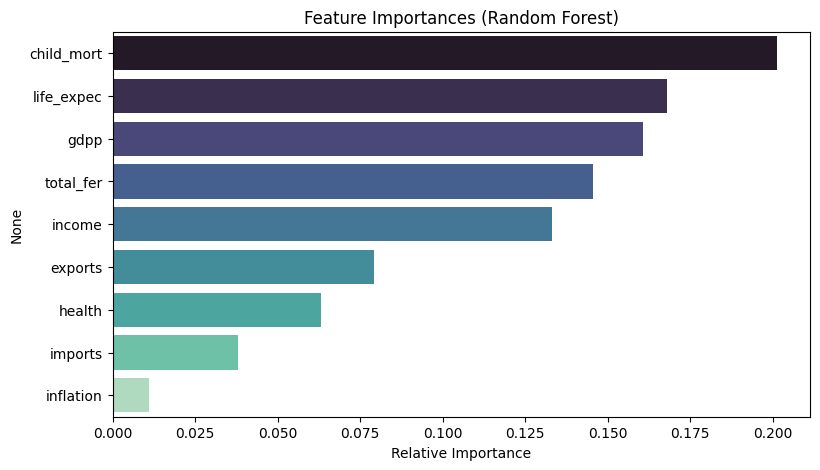

In [19]:
# Plot feature importances from Random Forest
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 5))
sns.barplot(x=importances[indices], y=X.columns[indices], palette='mako')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Relative Importance')
plt.show()


### Which variables are most important?
- **gdpp (GDP per capita)** is the most important feature for classification.
- **child_mort (Child Mortality)** is the second most important.
- **income** is third.
- This tells us that national economic output (GDP), healthcare standards (child mortality), and personal wealth (income) are the key drivers that define a country's development level.


# Conclusion & Key Findings
1. **Clustering Results**: We used **K-Means Clustering** to divide 167 countries into 3 groups: Underdeveloped (48 countries), Developing (92 countries), and Developed (27 countries). This segmentation helps identify countries in dire need of aid.
2. **Classification Performance**: We trained 4 classifiers. The **Random Forest** and **XGBoost** models perform exceptionally well, achieving near-perfect accuracy in predicting country development categories.
3. **Key Drivers**: Feature importance analysis showed that **GDP per capita**, **Child Mortality**, and **Income** are the three most critical indicators of development status.
